posgres


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Style configuration
sns.set_style('whitegrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.titleweight'] = 'bold'

# Reproducibility
np.random.seed(42)
print("Libraries loaded. matplotlib:", plt.matplotlib.__version__, "| seaborn:", sns.__version__)

Libraries loaded. matplotlib: 3.10.6 | seaborn: 0.13.2


- rcParams (runtime configuration parameter)
- different parameters pass garna milxa


In [3]:
n = 500
demo = pd.DataFrame({
    'age': np.random.normal(35, 10, n).clip(18, 70).astype(int),
    'income': np.random.lognormal(10.5, 0.5, n).round(2),
    'spending_score': np.random.beta(2, 5, n) * 100,
    'years_customer': np.random.exponential(3, n).clip(0, 15).round(1),
    'gender': np.random.choice(['Male', 'Female'], n, p=[0.48, 0.52]),
    'city': np.random.choice(['Kathmandu', 'Pokhara', 'Lalitpur', 'Bhaktapur', 'Biratnagar'],
                              n, p=[0.40, 0.20, 0.20, 0.10, 0.10]),
    'plan': np.random.choice(['Basic', 'Standard', 'Premium'], n, p=[0.5, 0.3, 0.2]),
    'satisfaction': np.random.choice([1, 2, 3, 4, 5], n, p=[0.05, 0.10, 0.20, 0.40, 0.25]),
})
# Inject a realistic relationship: spending grows with income
demo['spending_score'] = (demo['spending_score'] + (demo['income'] / 2000)).clip(0, 100)
demo.head()

,age,income,spending_score,years_customer,gender,city,plan,satisfaction
0,39,57704.40,66.503247,4.1,Female,Biratnagar,Basic,5
1,33,94344.51,81.060346,2.0,Male,Lalitpur,Basic,4
2,41,18046.67,42.509027,2.0,Female,Biratnagar,Basic,1
3,50,48121.51,68.055396,5.5,Male,Kathmandu,Basic,4
4,32,26230.52,62.894024,1.3,Female,Lalitpur,Premium,5


In [4]:
demo.dtypes

age                 int64
income            float64
spending_score    float64
years_customer    float64
gender             object
city               object
plan               object
satisfaction        int64
dtype: object

In [5]:
type(demo)

pandas.core.frame.DataFrame

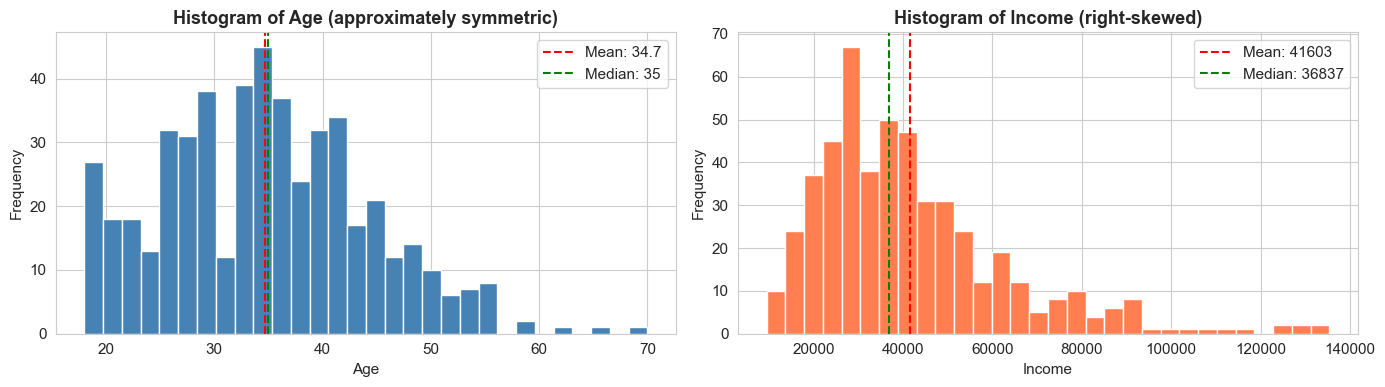

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Age - roughly normal
axes[0].hist(demo['age'], bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('Histogram of Age (approximately symmetric)')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Frequency')
axes[0].axvline(demo['age'].mean(), color='red', linestyle='--', label=f'Mean: {demo["age"].mean():.1f}')
axes[0].axvline(demo['age'].median(), color='green', linestyle='--', label=f'Median: {demo["age"].median():.0f}')
axes[0].legend()

# Income - right-skewed (lognormal)
axes[1].hist(demo['income'], bins=30, color='coral', edgecolor='white')
axes[1].set_title('Histogram of Income (right-skewed)')
axes[1].set_xlabel('Income')
axes[1].set_ylabel('Frequency')
axes[1].axvline(demo['income'].mean(), color='red', linestyle='--', label=f'Mean: {demo["income"].mean():.0f}')
axes[1].axvline(demo['income'].median(), color='green', linestyle='--', label=f'Median: {demo["income"].median():.0f}')
axes[1].legend()

plt.tight_layout()
plt.show()

# subplot
- divides the fig size 
- subplots(1, 2, figsize=(14, 4)) here the the 1,2 is it divides the fig in two parts and the another is the figsize
- axes[0].hist(demo['age'], bins=25, color='steelblue', edgecolor='white'). ( histogram plot)  age bins= 25 means 25 ota age 
- axes[0].axvline(demo['age'].mean(), color='red', linestyle='--', label=f'Mean: {demo["age"].mean():.1f}')


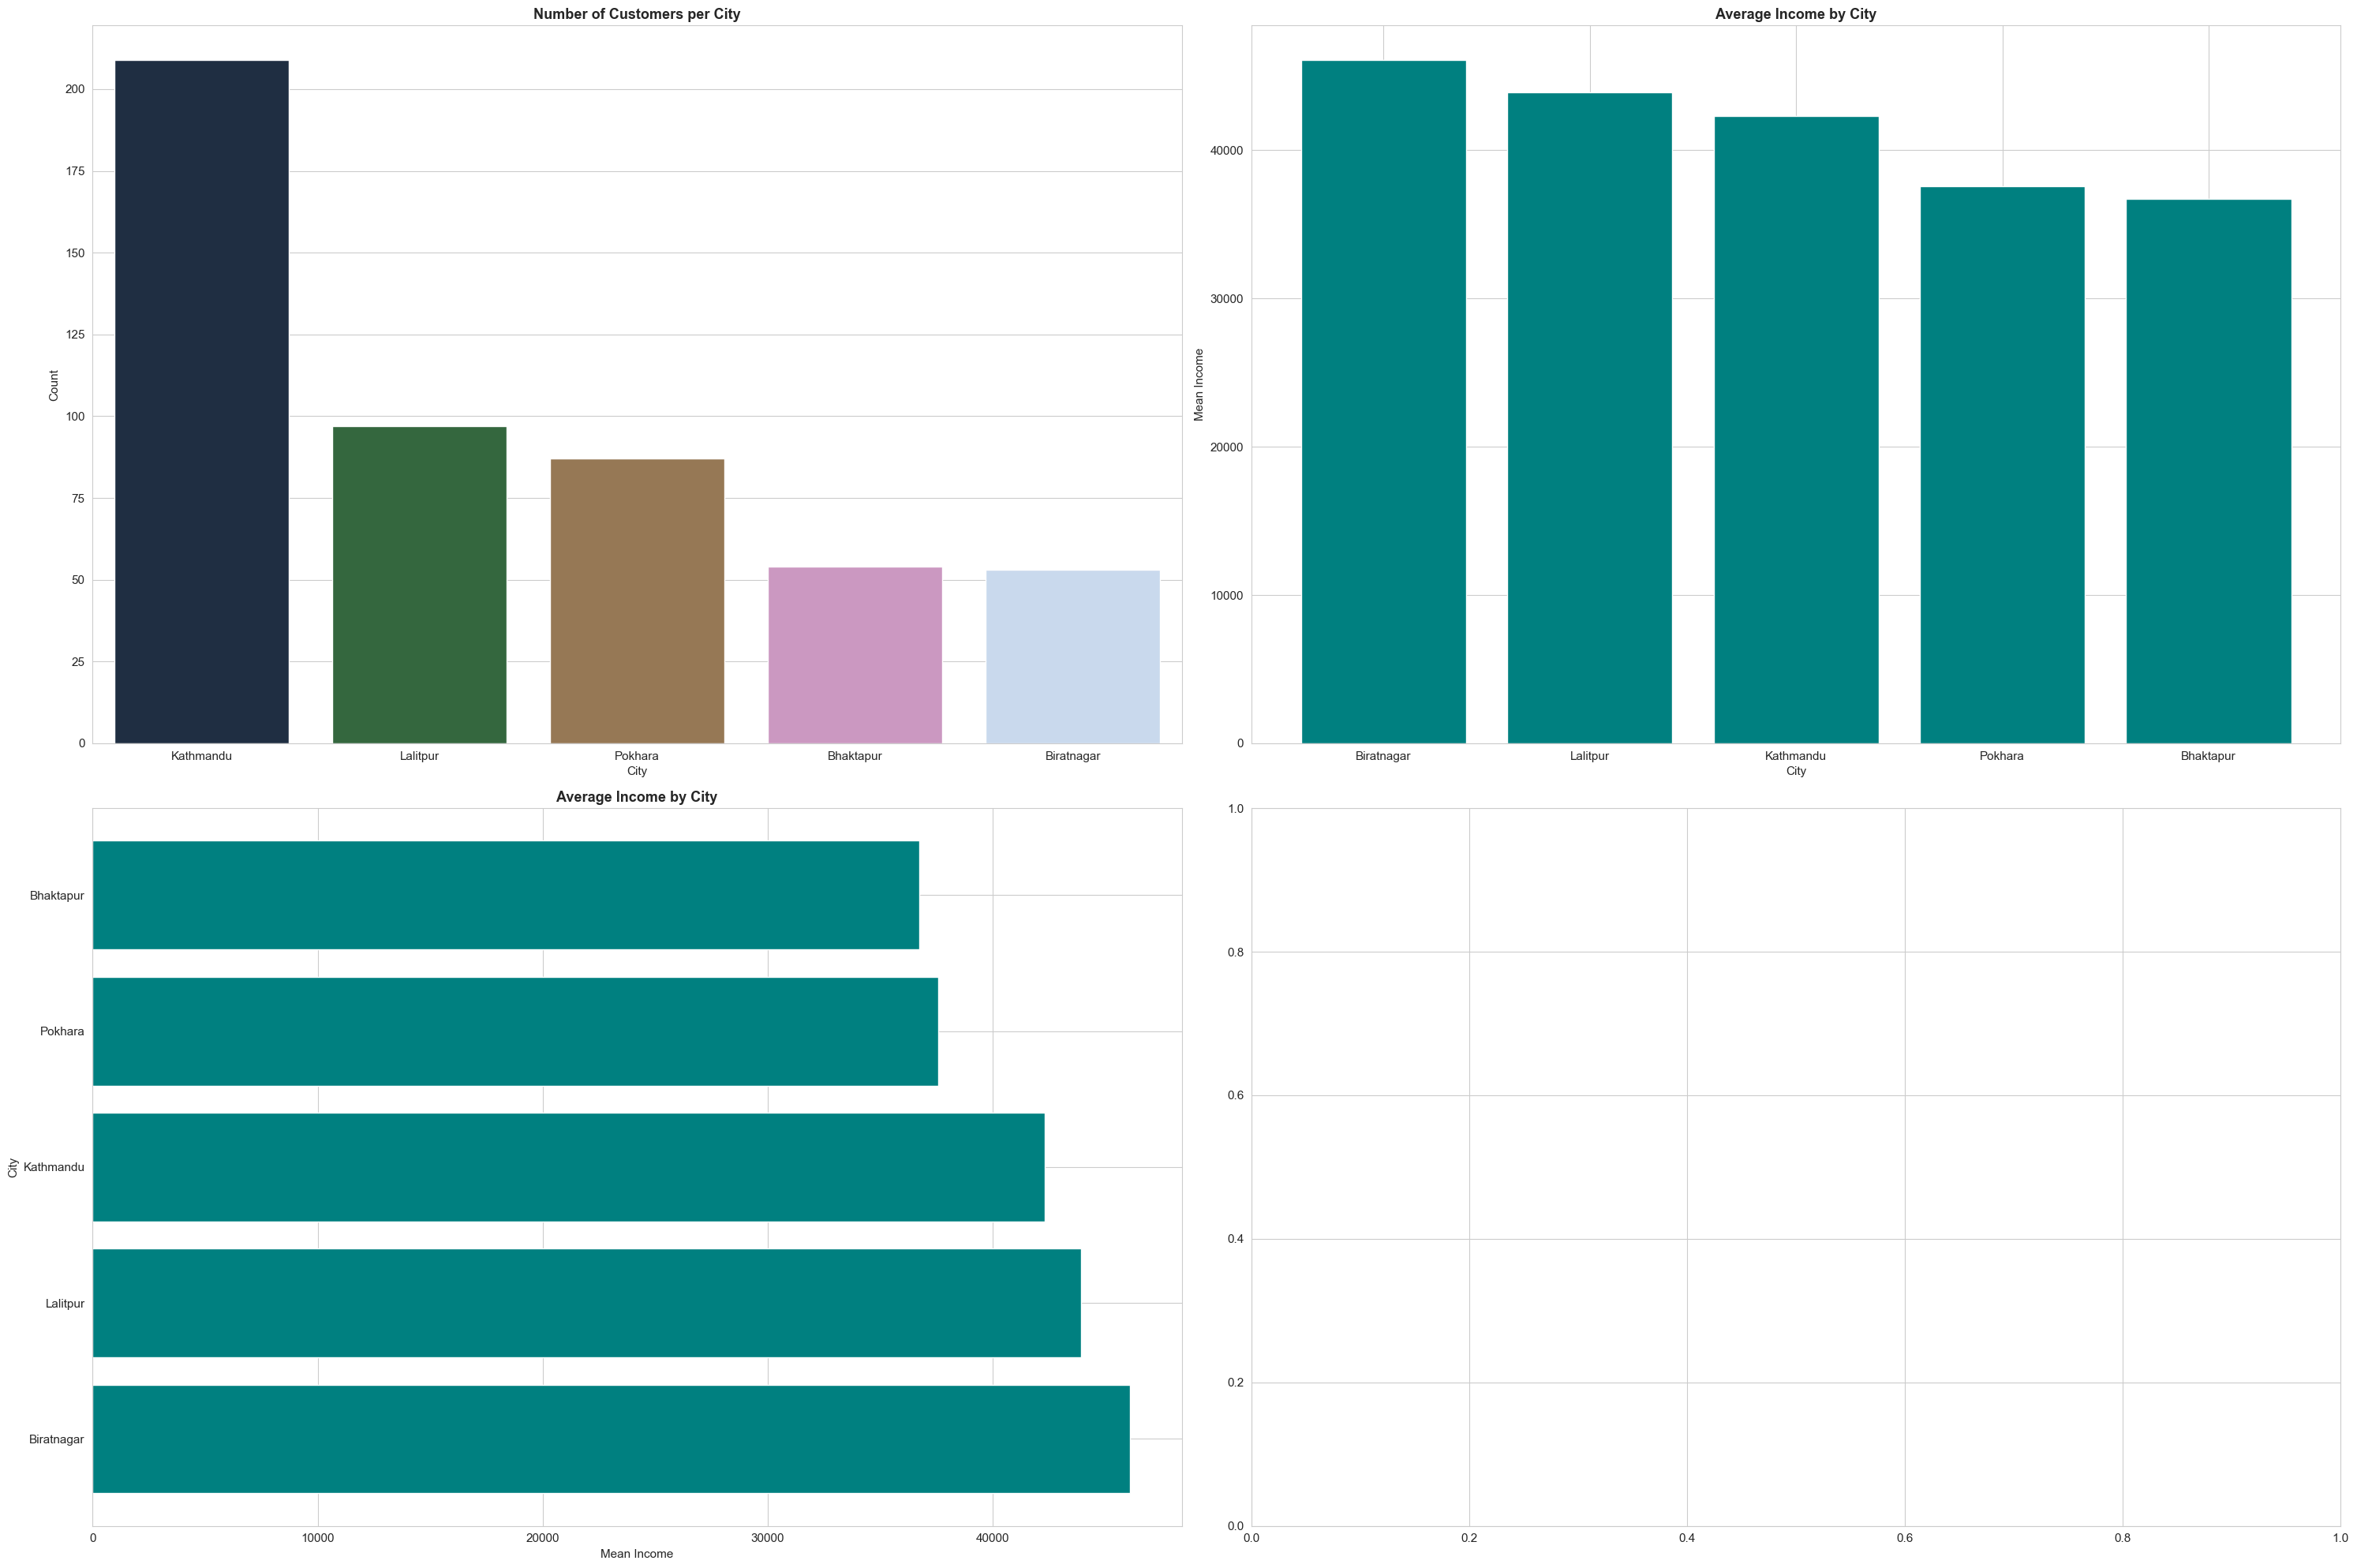

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(30, 20))

# Count plot - sorted
order = demo['city'].value_counts().index
sns.countplot(data=demo, x='city', order=order, ax=axes[0][0], palette='cubehelix')
axes[0][0].set_title('Number of Customers per City')
axes[0][0].set_xlabel('City')
axes[0][0].set_ylabel('Count')

# Aggregated bar chart - mean income per city
city_income = demo.groupby('city')['income'].mean().sort_values(ascending=False)
axes[0][1].bar(city_income.index, city_income.values, color='teal', edgecolor='white')
axes[0][1].set_title('Average Income by City')
axes[0][1].set_xlabel('City')
axes[0][1].set_ylabel('Mean Income')



# newly added chart
city_income = demo.groupby('city')['income'].mean().sort_values(ascending=False)
axes[1][0].barh(city_income.index, city_income.values,  color='teal', edgecolor='white')
axes[1][0].set_title('Average Income by City')
axes[1][0].set_xlabel('Mean Income')
axes[1][0].set_ylabel('City')


plt.tight_layout()
plt.show()


In [8]:
city_income = demo.groupby('city')['income'].mean().sort_values(ascending=False)
city_income

city
Biratnagar    46102.210189
Lalitpur      43921.577835
Kathmandu     42320.848421
Pokhara       37572.835172
Bhaktapur     36733.056296
Name: income, dtype: float64

In [9]:
demo.columns

Index(['age', 'income', 'spending_score', 'years_customer', 'gender', 'city',
       'plan', 'satisfaction'],
      dtype='object')

In [10]:
demo['city'].value_counts()

city
Kathmandu     209
Lalitpur       97
Pokhara        87
Bhaktapur      54
Biratnagar     53
Name: count, dtype: int64

NameError: name 'colors' is not defined

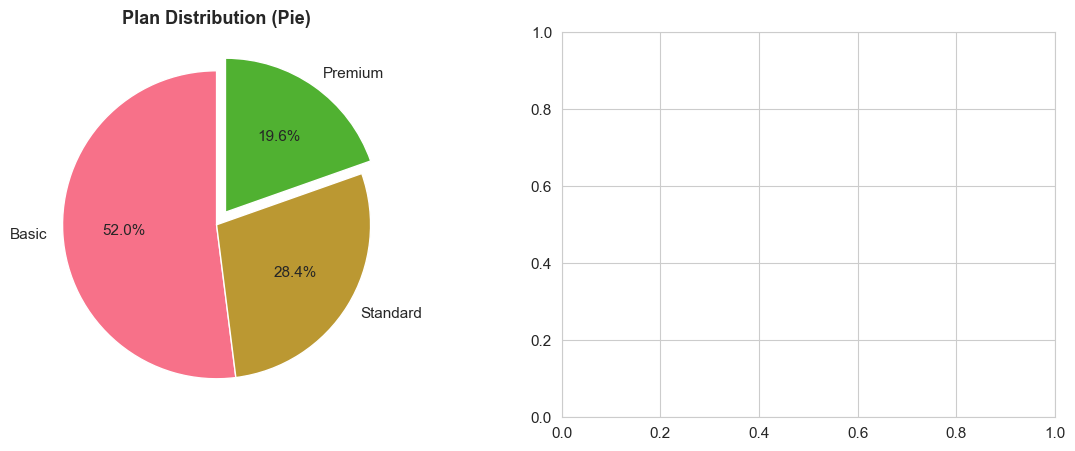

In [12]:
plan_counts = demo['plan'].value_counts()
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pie chart
# colors = ['#FF6B6B', '#4ECDC4', '#45B7D1'] # color has the default values. need not for the explicit.
axes[0].pie(plan_counts, labels=plan_counts.index, explode = (0,0,0.1),
            autopct='%1.1f%%', startangle=90)
axes[0].set_title('Plan Distribution (Pie)') # explode(0,0,1) it means the max proportion is first index and second max is second proportion and show on

# Same data as bar - usually clearer
axes[1].bar(plan_counts.index, plan_counts.values, color=colors, edgecolor='white')
axes[1].set_title('Plan Distribution (Bar) — usually easier to read')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

In [49]:
help(plt.pie)

Help on function pie in module matplotlib.pyplot:

pie(
    x: 'ArrayLike',
    *,
    explode: 'ArrayLike | None' = None,
    labels: 'Sequence[str] | None' = None,
    colors: 'ColorType | Sequence[ColorType] | None' = None,
    autopct: 'str | Callable[[float], str] | None' = None,
    pctdistance: 'float' = 0.6,
    shadow: 'bool' = False,
    labeldistance: 'float | None' = 1.1,
    startangle: 'float' = 0,
    radius: 'float' = 1,
    counterclock: 'bool' = True,
    wedgeprops: 'dict[str, Any] | None' = None,
    textprops: 'dict[str, Any] | None' = None,
    center: 'tuple[float, float]' = (0, 0),
    frame: 'bool' = False,
    rotatelabels: 'bool' = False,
    normalize: 'bool' = True,
    hatch: 'str | Sequence[str] | None' = None,
    data=None
) -> 'tuple[list[Wedge], list[Text]] | tuple[list[Wedge], list[Text], list[Text]]'
    Plot a pie chart.

    Make a pie chart of array *x*.  The fractional area of each wedge is
    given by ``x/sum(x)``.

    The wedges are plotted 

- if have to only show the premium outside the chart we use the explode


In [50]:
explode = (0,1,0)
